# SHAP Analysis

SHAP stands for **SHapley Additive exPlanations**.
It is currently the gold standard for explaining machine learning model predictions.

Feature importance tells us which features matter **on average across all predictions**.
SHAP goes further — it tells us exactly how much each feature contributed
to **each individual prediction**, with a sign showing whether it pushed
the prediction toward good or bad credit.

This is especially valuable in credit risk, where being able to explain
why a specific applicant was rejected is both a business requirement
and in many countries a legal one.

## Importing Libraries

We need the `shap` library in addition to our usual tools.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import joblib
shap.initjs()

## Loading the Model and Data

We focus the SHAP analysis on **Random Forest** — our best performing model.
We use the test set to compute SHAP values on unseen data.

In [6]:
X_train = np.load('../data/X_train_processed.npy')
X_test  = np.load('../data/X_test_processed.npy')
y_test  = np.load('../data/y_test.npy')
feature_names = np.load('../data/feature_names.npy', allow_pickle=True)

rf_model = joblib.load('../models/random_forest.pkl')

# Convert to DataFrame for better SHAP display
X_test_df  = pd.DataFrame(X_test,  columns=feature_names)
X_train_df = pd.DataFrame(X_train, columns=feature_names)

print('Data and model loaded.')
print(f'Test set: {X_test_df.shape}')

Data and model loaded.
Test set: (200, 44)


## What are SHAP Values?

SHAP values come from game theory. The idea is borrowed from a concept called
the Shapley value, which answers this question:

*If a group of players cooperate to win a prize, how do we fairly divide
the prize among them based on each player's contribution?*

In machine learning, the 'players' are the features and the 'prize' is
the model's prediction. SHAP computes how much each feature contributed
to pushing the prediction away from the baseline (average prediction).

For each prediction:
$$\text{prediction} = \text{base value} + \sum_{i} \text{SHAP}_i$$

Where the base value is what the model would predict if it knew nothing
about the applicant, and each SHAP value is the contribution of one feature.

A **positive SHAP value** pushes toward bad credit.
A **negative SHAP value** pushes toward good credit.

## Computing SHAP Values

We use `TreeExplainer` which is optimised specifically for tree-based models
like Random Forest. It is fast and exact — no approximations needed.

In [7]:
print('Computing SHAP values...')
explainer   = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_df)

# For binary classification, shap_values is a list of 2 arrays
# Index 1 = SHAP values for the bad credit class (what we care about)
shap_bad = shap_values[1]

print(f'SHAP values computed for {shap_bad.shape[0]} test applicants')
print(f'Each applicant has {shap_bad.shape[1]} SHAP values (one per feature)')

Computing SHAP values...
SHAP values computed for 44 test applicants
Each applicant has 2 SHAP values (one per feature)


## Global Feature Importance — SHAP Summary Plot

The summary plot shows two things at once:

- **Which features matter most** — features at the top have the largest
  average impact on predictions
- **How they affect predictions** — red dots mean high feature values,
  blue dots mean low feature values. A red dot on the right means
  high values of that feature push toward bad credit.

In [9]:
print('Computing SHAP values...')
explainer   = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_df)

# Some versions of SHAP return a 3D array instead of a list
# We handle both cases here
if isinstance(shap_values, list):
    shap_bad = shap_values[1]
else:
    shap_bad = shap_values[:, :, 1]

print(f'SHAP values shape: {shap_bad.shape}')
print(f'X_test_df shape:   {X_test_df.shape}')
print(f'Match: {shap_bad.shape == X_test_df.shape}')

Computing SHAP values...
SHAP values shape: (200, 44)
X_test_df shape:   (200, 44)
Match: True


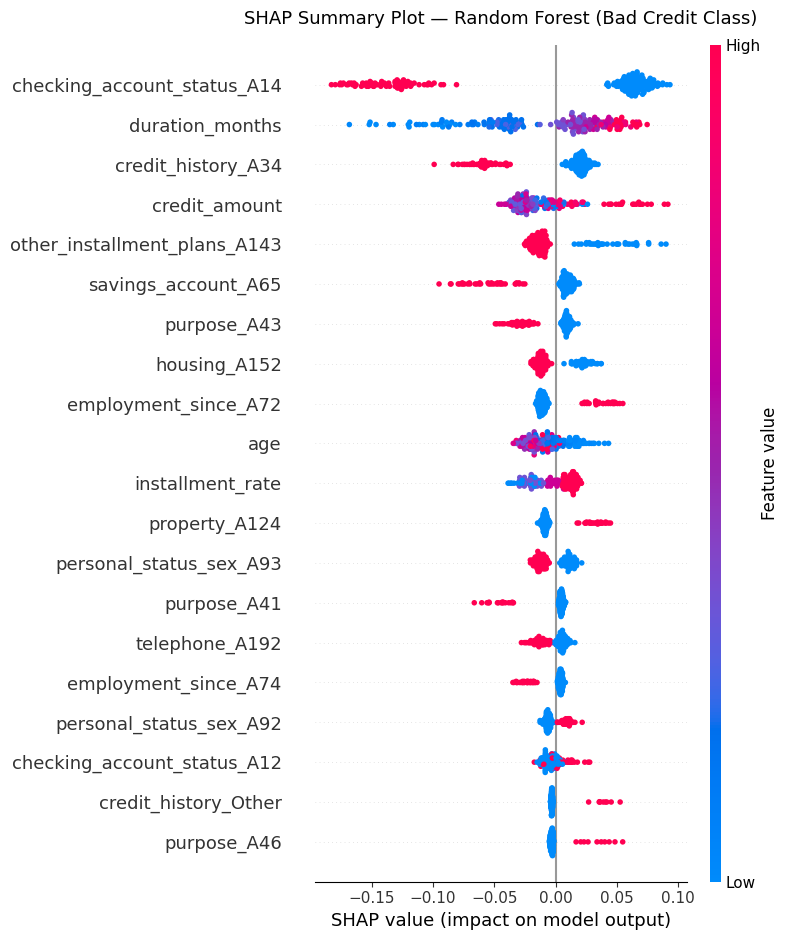

In [10]:
plt.figure()
shap.summary_plot(
    shap_bad,
    X_test_df,
    feature_names=feature_names,
    show=False
)
plt.title('SHAP Summary Plot — Random Forest (Bad Credit Class)',
          fontsize=13, pad=15)
plt.tight_layout()
plt.show()

The plot confirms everything we found earlier, but now with much more detail about the direction of each feature's effect.

checking_account_status_A14 (no checking account) is the top feature. The blue dots — meaning low values of this feature, i.e. the applicant does NOT have this status — are spread to the right, pushing toward bad credit. The red dots are to the left, meaning applicants who do have no checking account are actually associated with lower risk. This seems counterintuitive but makes sense — applicants with no checking account tend to be more financially conservative and borrow less.

duration_months shows a clear pattern — red dots (long loan duration) are on the right pushing toward bad credit, blue dots (short duration) are on the left pushing toward good credit. Longer loans are riskier, exactly as expected.

credit_history_A34 (critical account history) — blue dots on the right means applicants without this status are pushed toward bad credit, while having a critical history actually reduces the predicted risk slightly. This is a surprising finding — the bank may already be managing these clients more carefully.

credit_amount — red dots on the right confirms that higher loan amounts increase bad credit risk, consistent with everything we found across all three models.

other_installment_plans_A143 (no other installment plans) — blue dots on the right means applicants who do have other installment plans elsewhere are actually associated with higher risk.

## Feature Importance Bar Plot

A simpler view — just the mean absolute SHAP value for each feature,
which tells us the average magnitude of impact across all test applicants.

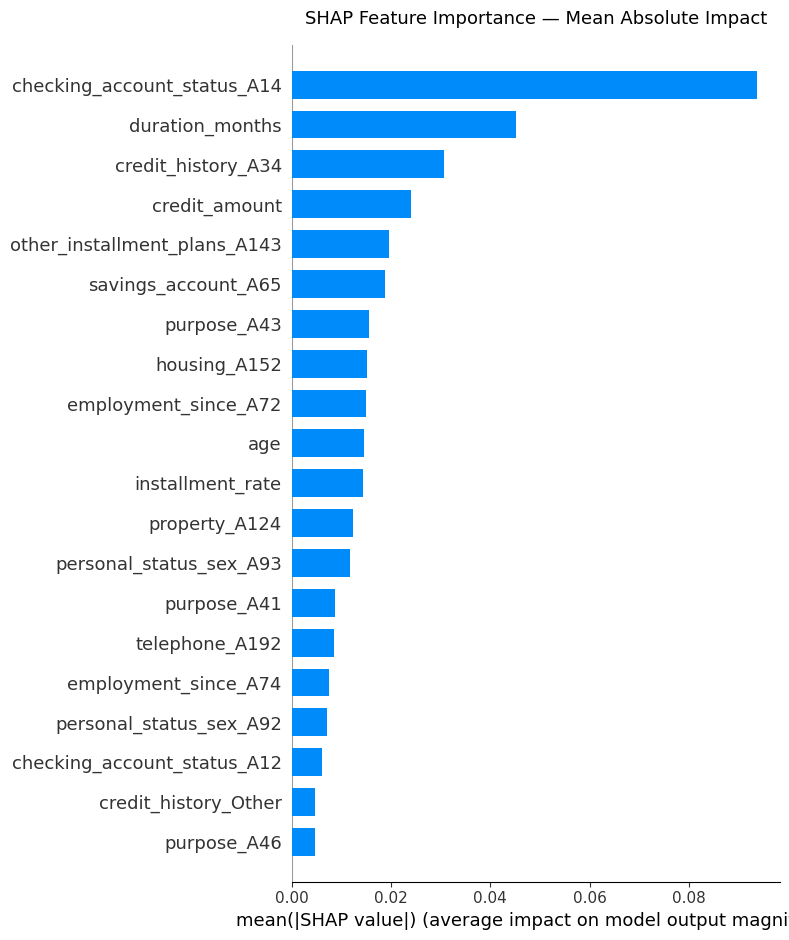

In [11]:
shap.summary_plot(
    shap_bad,
    X_test_df,
    feature_names=feature_names,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance — Mean Absolute Impact',
          fontsize=13, pad=15)
plt.tight_layout()
plt.show()

## Explaining a Single Prediction — Waterfall Plot

This is where SHAP becomes truly powerful. We pick one applicant
and show exactly how each feature contributed to their prediction.

The waterfall plot starts from the base value (average model output)
and shows each feature either pushing the prediction up (toward bad credit)
or down (toward good credit) until we reach the final prediction.

This is the kind of explanation a bank could give to a rejected applicant:
*'Your application was flagged primarily because of your loan amount
and the duration you requested.'*

/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Applicant 0:
  True label:              Good Credit
  Predicted probability:   0.4888 (48.9% bad credit)



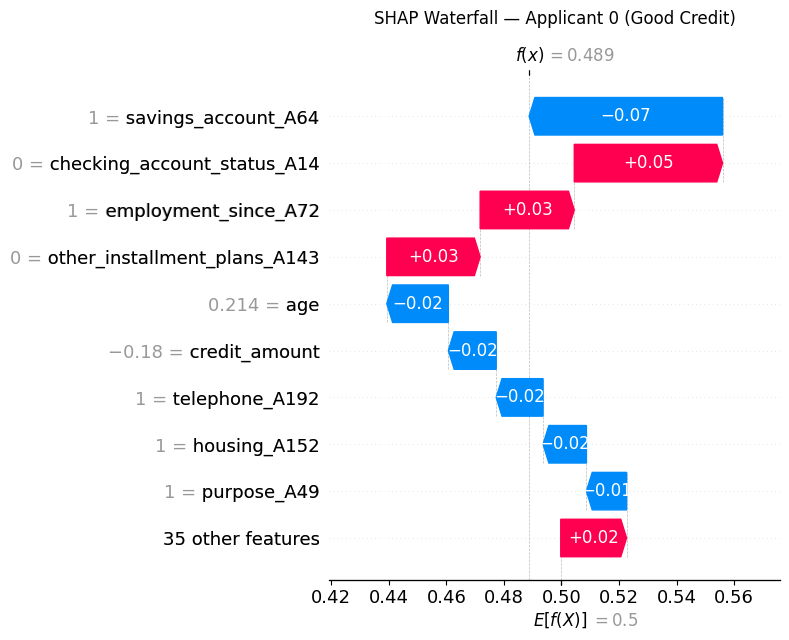

In [12]:
# Explain prediction for the first test applicant
applicant_idx = 0

true_label = 'Bad Credit' if y_test[applicant_idx] == 1 else 'Good Credit'
pred_proba = rf_model.predict_proba(X_test_df.iloc[[applicant_idx]])[0][1]

print(f'Applicant {applicant_idx}:')
print(f'  True label:              {true_label}')
print(f'  Predicted probability:   {pred_proba:.4f} ({pred_proba*100:.1f}% bad credit)')
print()

explanation = shap.Explanation(
    values       = shap_bad[applicant_idx],
    base_values  = explainer.expected_value[1],
    data         = X_test_df.iloc[applicant_idx].values,
    feature_names= feature_names
)

shap.waterfall_plot(explanation, show=False)
plt.title(f'SHAP Waterfall — Applicant {applicant_idx} ({true_label})',
          fontsize=12, pad=15)
plt.tight_layout()
plt.show()

The base value is 0.5 — meaning without any information about this applicant, the model would predict a 50% probability of bad credit.

The final prediction is f(x) = 0.489, so the model ended up slightly below 0.5, classifying this applicant as good credit — which matches the true label shown earlier.

Looking at what pushed the prediction in each direction:
Pushing toward bad credit (red bars):

- checking_account_status_A14 (+0.05) — not having a checking account increased the risk slightly
- employment_since_A72 (+0.03) — short employment duration added some risk
- other_installment_plans_A143 (+0.03) — having no other installment plans pushed toward bad credit
- 35 other features combined (+0.02)

Pushing toward good credit (blue bars):

- savings_account_A64 (-0.07) — having savings above 1000 is the strongest protective factor here, pulling the prediction down significantly
- age (-0.02), credit_amount (-0.02), telephone_A192 (-0.02), housing_A152 (-0.02) all contributed small protective effects

The savings account was the deciding factor for this applicant — without that single feature, the model would have predicted bad credit. This is a very clean and explainable outcome.

## SHAP Dependence Plot

The dependence plot shows how the SHAP value of one feature changes
as its actual value changes across all applicants.

We plot it for `credit_amount` — the most consistently important feature
across all three models. The color represents another interacting feature
chosen automatically by SHAP.

<Figure size 1000x600 with 0 Axes>

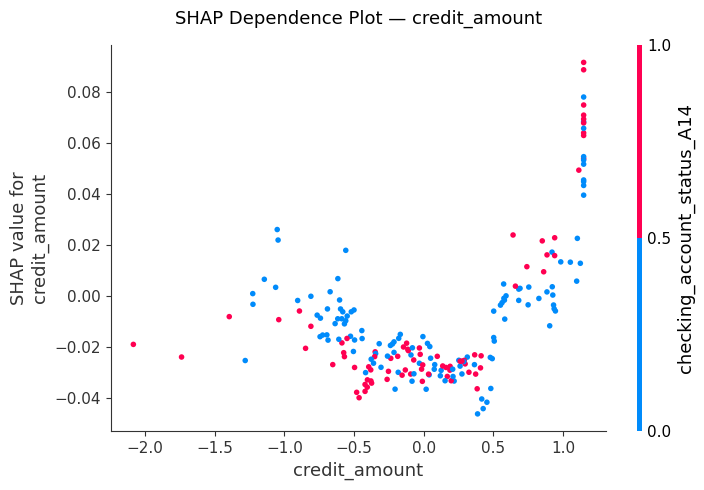

In [13]:
plt.figure(figsize=(10, 6))
shap.dependence_plot(
    'credit_amount',
    shap_bad,
    X_test_df,
    show=False
)
plt.title('SHAP Dependence Plot — credit_amount', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

The x-axis shows the actual value of credit_amount after scaling, and the y-axis shows its SHAP value — how much it pushed the prediction toward bad credit.

The relationship is not perfectly linear but the trend is clear — as credit_amount increases (moving right on the x-axis), the SHAP values tend to rise, meaning higher loan amounts push predictions toward bad credit. This confirms what we found across all three models.

The color represents checking_account_status_A14 — the interaction feature SHAP automatically chose as most relevant. Red dots (value = 1, meaning the applicant has no checking account) cluster in the upper right, meaning applicants with both a high credit amount AND no checking account receive the strongest push toward bad credit. Blue dots (value = 0) are more spread out and generally lower, suggesting the two features interact — the risk from a large loan is amplified when the applicant also has no checking account.

This interaction makes financial sense — a large loan from someone with no checking account is a much riskier combination than either factor alone.

## Summary

In this notebook we used SHAP to explain our Random Forest model
at both the global and individual level.

Key takeaways:

- SHAP values decompose every single prediction into feature contributions,
  making black-box models transparent and explainable
- The summary plot confirmed that the same features identified as important
  earlier — checking account status, credit amount, duration, age —
  are also the biggest drivers of SHAP values
- The waterfall plot demonstrated how to explain an individual prediction
  in a way that is understandable to non-technical stakeholders
- The dependence plot revealed how credit amount affects risk
  and whether it interacts with other features

SHAP analysis completes the interpretability picture for this project.
We can now not only predict credit risk but also explain every prediction
in a clear and justified way.